/var/folders/35/fpqmwycx1ln5c7s2lxkvbtg80000gp/T/ipykernel_1203/2350011880.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed


MONTE CARLO PORTFOLIO SIMULATION (3 ASSETS)

--- Performance ---
Mean CAGR:                 4.84%
Annual Volatility:         5.85%
Sharpe Ratio (rf=1.00%): 0.66

--- Risk ---
VaR (95%, 5Y):             18.40%
Expected Shortfall (95%):  10.48%

--- Drawdown ---
Average Max Drawdown:      -11.01%
Worst Max Drawdown:        -28.30%

--- Tail Risk ---
Worst Return :             -11.27%
Average Bottom 10%:        16.56%


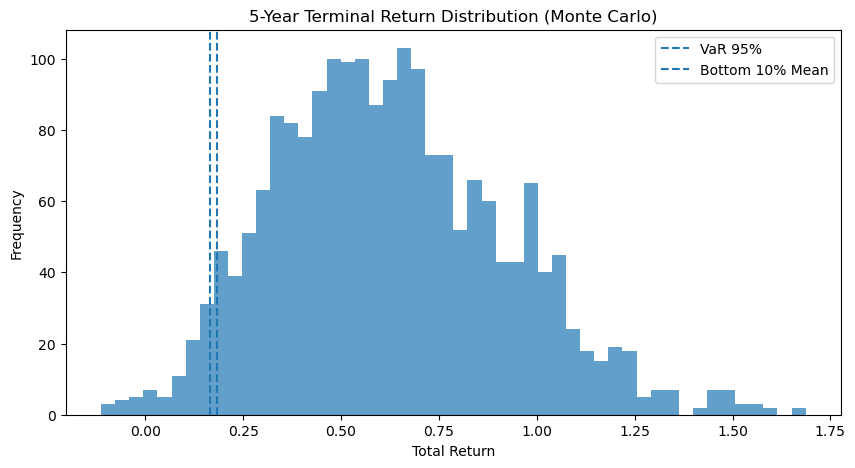



=== MONTE CARLO SCENARIO TABLE ===

         Scenario Final Portfolio Value
Pessimistic (10%)            126,692.53
     Median (50%)            160,475.90
 Optimistic (90%)            202,352.31


In [1]:
"""
Monte Carlo Portfolio Simulation using Geometric Brownian Motion (GBM).

Features:
- Multi-asset correlated simulation
- Log-return modeling
- Risk metrics: VaR, Expected Shortfall, Drawdown
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf

# ----------------- DATA -----------------

def get_data(tickers, start_date, end_date):
    prices = yf.download(tickers, start=start_date, end=end_date)['Close']
    
    # Log returns
    log_returns = np.log(prices / prices.shift(1)).dropna()
    
    mean_returns = log_returns.mean()
    cov_matrix = log_returns.cov()
    
    return mean_returns, cov_matrix

def compute_max_drawdown(path):
    running_max = np.maximum.accumulate(path)
    drawdowns = path / running_max - 1
    return drawdowns.min()

# ----------------- PARAMETERS -----------------

tickers = ['^GSPC', 'AGG', 'GC=F']
years_data=30 #number of years for data analysis
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days= years_data*365)

mean_returns, cov_matrix = get_data(tickers, start_date, end_date)

# Put the weights sum=1
weights =[0.7,0.2,0.1] 

num_simulations = 2000
#define time horizon for investment
time_horizon_days = 252 * 10
years = time_horizon_days / 252

initial_portfolio = 100000
risk_free_rate = 0.01

# ----------------- PREPARATION -----------------

# Numerical stability adjustment
cov_matrix += np.eye(len(cov_matrix)) * 1e-10

cholesky_matrix = np.linalg.cholesky(cov_matrix)

# GBM drift term
drift = mean_returns.values - 0.5 * np.diag(cov_matrix)

portfolio_sim = np.zeros((time_horizon_days, num_simulations))

# ----------------- SIMULATION -----------------

for i in range(num_simulations):
    random_shocks = np.random.normal(size=(len(weights), time_horizon_days))
    
    simulated_log_returns = drift.reshape(-1, 1) + cholesky_matrix @ random_shocks
    portfolio_log_returns = weights @ simulated_log_returns
    
    portfolio_path = initial_portfolio * np.exp(np.cumsum(portfolio_log_returns))
    
    portfolio_sim[:, i] = portfolio_path

# ----------------- METRICS -----------------

terminal_values = portfolio_sim[-1, :]
terminal_returns = terminal_values / initial_portfolio - 1

# CAGR
cagr = (terminal_values / initial_portfolio) ** (1 / years) - 1
mean_cagr = np.mean(cagr)

# Annualized volatility
portfolio_log_returns = np.diff(np.log(portfolio_sim), axis=0)
annual_volatility = np.std(portfolio_log_returns) * np.sqrt(252)

# Sharpe ratio
sharpe_ratio = (mean_cagr - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

# Risk metrics
var_95 = np.percentile(terminal_returns, 5)
es_95 = terminal_returns[terminal_returns <= var_95].mean()

# Drawdown
max_drawdowns = np.array([compute_max_drawdown(portfolio_sim[:, i]) for i in range(num_simulations)])
average_mdd = max_drawdowns.mean()
worst_mdd = max_drawdowns.min()

# Tail risk
worst_return = terminal_returns.min()
bottom_10_threshold = np.percentile(terminal_returns, 10)
average_bottom_10 = terminal_returns[terminal_returns <= bottom_10_threshold].mean()

# ----------------- OUTPUT -----------------

print("=" * 60)
print(f"MONTE CARLO PORTFOLIO SIMULATION ({len(tickers)} ASSETS)")
print("=" * 60)

print("\n--- Performance ---")
print(f"Mean CAGR:                 {mean_cagr:.2%}")
print(f"Annual Volatility:         {annual_volatility:.2%}")
print(f"Sharpe Ratio (rf={risk_free_rate:.2%}): {sharpe_ratio:.2f}")

print("\n--- Risk ---")
print(f"VaR (95%):             {var_95:.2%}")
print(f"Expected Shortfall (95%):  {es_95:.2%}")

print("\n--- Drawdown ---")
print(f"Average Max Drawdown:      {average_mdd:.2%}")
print(f"Worst Max Drawdown:        {worst_mdd:.2%}")

print("\n--- Tail Risk ---")
print(f"Worst Return :             {worst_return:.2%}")
print(f"Average Bottom 10%:        {average_bottom_10:.2%}")

print("=" * 60)

# ----------------- PLOT -----------------

plt.figure(figsize=(10, 5))
plt.hist(terminal_returns, bins=50, alpha=0.7)
plt.axvline(var_95, linestyle='--', label='VaR 95%')
plt.axvline(average_bottom_10, linestyle='--', label='Bottom 10% Mean')

plt.title(' Terminal Return Distribution (Monte Carlo)')
plt.xlabel('Total Return')
plt.ylabel('Frequency')
plt.legend()

plt.show()

# ----------------- SCENARIO TABLE (ADDED) -----------------

p10 = np.percentile(terminal_values, 10)
p50 = np.percentile(terminal_values, 50)
p90 = np.percentile(terminal_values, 90)

scenario_table = pd.DataFrame({
    "Scenario": ["Pessimistic (10%)", "Median (50%)", "Optimistic (90%)"],
    "Final Portfolio Value": [p10, p50, p90]
})

print("\n\n=== MONTE CARLO SCENARIO TABLE ===\n")
print(scenario_table.to_string(index=False, formatters={
    "Final Portfolio Value": "{:,.2f}".format
}))
